# Setup

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import pandas as pd
import numpy as np

from astropy.constants import R_sun, L_sun, sigma_sb, G, M_earth, R_earth, R

import matplotlib.pyplot as plt
from matplotlib.animation import PillowWriter
import matplotlib.animation as animation
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

import tensorflow as tf

from geexhp import datasetup as dset
from geexhp import datavis as dvis
from geexhp import datagen

dvis.configure_matplotlib()

E0000 00:00:1785429855.722463  234620 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785429855.730417  234620 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1785429855.748883  234620 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785429855.748908  234620 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785429855.748912  234620 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785429855.748914  234620 computation_placer.cc:177] computation placer already registered. Please check linka

# Looking some data

In [2]:
dg = datagen.DataGen(stage="modern")
dg.generator(0, 5, random_atm=False, output_file="test_modern")

>> Range 0-5 done in 0:00:18.172565. Saved to data/test_modern.parquet.


In [3]:
df = pd.read_parquet("data/test_modern.parquet")
# data = df.iloc[0][df.columns[:-24]].to_dict()
# result = "\n".join([f"<{key}>{value}" for key, value in data.items()])

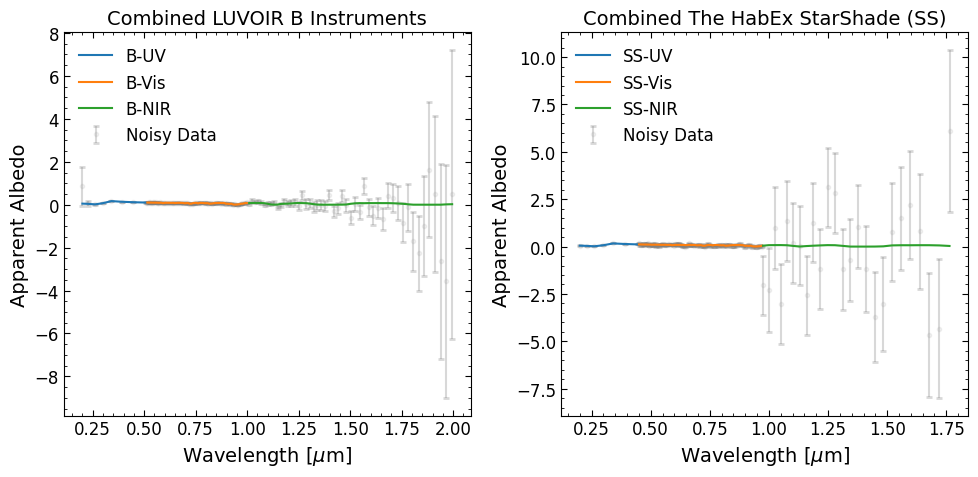

In [4]:
dvis.plot_spectrum(df, index=1, noise=True)
plt.show()

In [5]:
os.remove("data/test_modern.parquet")
os.rmdir("data")

# Loading data (tfrecord)


In [4]:
tfrecord_file = "../data/test.tfrecord"  # This file has only cases with SNR PCLT > 3.0

feature_description = {
    "NOISY_ALBEDO_B-NIR": tf.io.VarLenFeature(tf.float32),
    "NOISY_ALBEDO_B-UV": tf.io.VarLenFeature(tf.float32),
    "NOISY_ALBEDO_B-Vis": tf.io.VarLenFeature(tf.float32),
    "NOISY_ALBEDO_SS-NIR": tf.io.VarLenFeature(tf.float32),
    "NOISY_ALBEDO_SS-UV": tf.io.VarLenFeature(tf.float32),
    "NOISY_ALBEDO_SS-Vis": tf.io.VarLenFeature(tf.float32),
    # Clean albedo (model line)
    "ALBEDO_B-NIR": tf.io.VarLenFeature(tf.float32),
    "ALBEDO_B-UV": tf.io.VarLenFeature(tf.float32),
    "ALBEDO_B-Vis": tf.io.VarLenFeature(tf.float32),
    "ALBEDO_SS-NIR": tf.io.VarLenFeature(tf.float32),
    "ALBEDO_SS-UV": tf.io.VarLenFeature(tf.float32),
    "ALBEDO_SS-Vis": tf.io.VarLenFeature(tf.float32),
    # Noise (error bars)
    "NOISE_B-NIR": tf.io.VarLenFeature(tf.float32),
    "NOISE_B-UV": tf.io.VarLenFeature(tf.float32),
    "NOISE_B-Vis": tf.io.VarLenFeature(tf.float32),
    "NOISE_SS-NIR": tf.io.VarLenFeature(tf.float32),
    "NOISE_SS-UV": tf.io.VarLenFeature(tf.float32),
    "NOISE_SS-Vis": tf.io.VarLenFeature(tf.float32),
    "OBJECT-RADIUS-REL-EARTH": tf.io.FixedLenFeature([], tf.float32),
    "OBJECT-GRAVITY": tf.io.FixedLenFeature([], tf.float32),
    "ATMOSPHERE-TEMPERATURE": tf.io.FixedLenFeature([], tf.float32),
    "ATMOSPHERE-PRESSURE": tf.io.FixedLenFeature([], tf.float32),
    "Earth_type": tf.io.FixedLenFeature([], tf.string),
    "CH4": tf.io.FixedLenFeature([], tf.float32),
    "CO2": tf.io.FixedLenFeature([], tf.float32),
    "H2O": tf.io.FixedLenFeature([], tf.float32),
    "N2": tf.io.FixedLenFeature([], tf.float32),
    "O2": tf.io.FixedLenFeature([], tf.float32),
    "O3": tf.io.FixedLenFeature([], tf.float32),
    "OBJECT-STAR-TYPE": tf.io.FixedLenFeature([], tf.string),
    "GEOMETRY-OBS-ALTITUDE": tf.io.FixedLenFeature([], tf.float32),
    "OBJECT-INCLINATION": tf.io.FixedLenFeature([], tf.float32),
    "OBJECT-SEASON": tf.io.FixedLenFeature([], tf.float32),
    "OBJECT-PHASE-ANGLE": tf.io.FixedLenFeature([], tf.float32),
}


def parse_example(example_proto):
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    parsed = {
        k: (tf.sparse.to_dense(v) if isinstance(v, tf.SparseTensor) else v)
        for k, v in parsed.items()
    }
    return parsed


ds = tf.data.TFRecordDataset(tfrecord_file).map(parse_example)

rows = []
for ex in ds:
    row = {}
    for k, v in ex.items():
        val = v.numpy()
        if isinstance(val, bytes):
            row[k] = val.decode("utf-8")
        elif np.ndim(val) == 0:
            row[k] = val.item()
        else:
            row[k] = val.tolist()
    rows.append(row)

df = pd.DataFrame(rows)
df.head()

,ALBEDO_B-NIR,ALBEDO_B-UV,ALBEDO_B-Vis,ALBEDO_SS-NIR,ALBEDO_SS-UV,ALBEDO_SS-Vis,NOISE_B-NIR,NOISE_B-UV,NOISE_B-Vis,NOISE_SS-NIR,...,H2O,N2,O2,O3,OBJECT-GRAVITY,OBJECT-INCLINATION,OBJECT-PHASE-ANGLE,OBJECT-RADIUS-REL-EARTH,OBJECT-SEASON,OBJECT-STAR-TYPE
0,"[0.10506915301084518, 0.10718519985675812, 0.0...","[0.0014044592389836907, 0.0008517602109350264,...","[0.09097832441329956, 0.08919604122638702, 0.0...","[0.06294457614421844, 0.10301811248064041, 0.1...","[0.0014044592389836907, 0.0008517602109350264,...","[0.11402770131826401, 0.11458750814199448, 0.1...","[0.0012685200199484825, 0.0012781500117853284,...","[0.05370759963989258, 0.006908710114657879, 0....","[0.0007651220075786114, 0.0007857860182411969,...","[0.0010527799604460597, 0.0011752600548788905,...",...,0.006209,0.401879,0.591360,1.476033e-06,9.471465,15.474450,86.185143,0.979564,284.439911,G
1,"[0.19119760394096375, 0.19180047512054443, 0.1...","[0.008316423743963242, 0.0033190918620675802, ...","[0.18187859654426575, 0.17974978685379028, 0.1...","[0.1667640209197998, 0.19072355329990387, 0.19...","[0.008316423743963242, 0.003319092094898224, 0...","[0.21284008026123047, 0.2123483419418335, 0.21...","[0.0034159100614488125, 0.003456090111285448, ...","[0.138264998793602, 0.016532400622963905, 0.00...","[0.0014999799896031618, 0.0015431999927386642,...","[0.012834900058805943, 0.017078399658203125, 0...",...,0.000593,0.820523,0.174933,8.208724e-07,12.744548,47.220985,55.873199,1.179993,319.850372,G
2,"[0.08554030954837799, 0.12112219631671906, 0.1...","[0.09649905562400818, 0.367184579372406, 0.329...","[0.17923837900161743, 0.17855408787727356, 0.1...","[0.08244819939136505, 0.08191221952438354, 0.1...","[0.09649905562400818, 0.367184579372406, 0.329...","[0.19466276466846466, 0.19364288449287415, 0.1...","[0.0018273800378665328, 0.0018695499747991562,...","[0.056564200669527054, 0.010356600396335125, 0...","[0.00104571005795151, 0.0010776499984785914, 0...","[0.0029981399420648813, 0.0036602700129151344,...",...,0.002094,0.982766,0.000000,0.000000e+00,13.065886,41.504078,53.033176,1.205439,24.842730,G
3,"[0.049774281680583954, 0.049736905843019485, 0...","[0.008595001883804798, 0.001154368044808507, 0...","[0.06106334924697876, 0.059179820120334625, 0....","[0.045632198452949524, 0.049702536314725876, 0...","[0.008595001883804798, 0.001154368044808507, 0...","[0.09591590613126755, 0.094641774892807, 0.092...","[0.0018485999898985028, 0.0018573199631646276,...","[0.05880440026521683, 0.008201530203223228, 0....","[0.0009502070024609566, 0.0009768620366230607,...","[0.001533780014142394, 0.0017498499946668744, ...",...,0.000273,0.972405,0.023522,1.838184e-06,13.319044,20.304594,71.511627,1.224102,23.958538,G
4,"[0.07504922896623611, 0.07716178148984909, 0.0...","[0.08256059885025024, 0.20357389748096466, 0.1...","[0.09289909154176712, 0.09251221269369125, 0.0...","[0.06541065126657486, 0.07448789477348328, 0.0...","[0.08256059885025024, 0.20357389748096466, 0.1...","[0.1022973507642746, 0.10169462859630585, 0.10...","[0.0016795600531622767, 0.0017119500553235412,...","[0.003032109932973981, 0.0019427599618211389, ...","[0.0010830899700522423, 0.0010852599516510963,...","[0.0017562200082466006, 0.0019510099664330482,...",...,0.000889,0.992117,0.000000,0.000000e+00,9.359010,36.864182,78.366211,0.971255,70.358292,F


In [5]:
df["Earth_type"].value_counts()

Earth_type
modern         3944
proterozoic    3701
archean        3353
Name: count, dtype: int64

# Figure 1

In [6]:
# Predefined wavelength arrays
WAVELENGTHS = {
    "B-UV": np.array(
        [
            0.2,
            0.22857143,
            0.26122449,
            0.29854227,
            0.34119117,
            0.38993277,
            0.44563745,
            0.50929994,
        ]
    ),
    "B-Vis": np.array(
        [
            0.515,
            0.51867857,
            0.52238342,
            0.52611473,
            0.52987269,
            0.5366575,
            0.53746934,
            0.5413084,
            0.54517489,
            0.549069,
            0.55299092,
            0.55694085,
            0.560919,
            0.56492557,
            0.56896075,
            0.57302475,
            0.57711779,
            0.58124006,
            0.58539177,
            0.58957314,
            0.59378438,
            0.5980257,
            0.60229731,
            0.60659943,
            0.61093229,
            0.61529609,
            0.61969106,
            0.62411742,
            0.62857541,
            0.63306523,
            0.63758712,
            0.64214132,
            0.64672804,
            0.65134753,
            0.65600001,
            0.66068572,
            0.66540491,
            0.6701578,
            0.67494464,
            0.67976568,
            0.68462114,
            0.6895113,
            0.69443638,
            0.69939664,
            0.70439233,
            0.7094237,
            0.71449101,
            0.71959452,
            0.72473448,
            0.72991116,
            0.73512481,
            0.7403757,
            0.7456641,
            0.75099027,
            0.75635448,
            0.76175702,
            0.76719814,
            0.77267812,
            0.77819725,
            0.78375581,
            0.78935406,
            0.7949923,
            0.80067082,
            0.8063899,
            0.81214983,
            0.8179509,
            0.8237934,
            0.82967764,
            0.83560391,
            0.84157251,
            0.84758374,
            0.85363791,
            0.85973532,
            0.86587629,
            0.87206112,
            0.87829013,
            0.88456363,
            0.89088194,
            0.89724539,
            0.90365428,
            0.91010895,
            0.91660973,
            0.92315694,
            0.92975092,
            0.936392,
            0.94308052,
            0.9498168,
            0.95660121,
            0.96343408,
            0.97031575,
            0.97724657,
            0.98422691,
            0.9912571,
            0.99833751,
        ]
    ),
    "B-NIR": np.array(
        [
            1.01,
            1.02442857,
            1.03906327,
            1.05390703,
            1.06896284,
            1.08423374,
            1.09972279,
            1.11543312,
            1.13136788,
            1.14753028,
            1.16392356,
            1.18055104,
            1.19741606,
            1.214522,
            1.23187232,
            1.24947049,
            1.26732007,
            1.28542464,
            1.30378785,
            1.32241339,
            1.34130501,
            1.36046651,
            1.37990175,
            1.39961463,
            1.41960913,
            1.43988926,
            1.4604591,
            1.48132281,
            1.50248456,
            1.52394862,
            1.54571932,
            1.56780102,
            1.59019818,
            1.6129153,
            1.63595694,
            1.65932776,
            1.68303244,
            1.70707576,
            1.73146256,
            1.75619774,
            1.78128628,
            1.80673322,
            1.8325437,
            1.85872289,
            1.88527608,
            1.91220859,
            1.93952586,
            1.96723337,
            1.9953367,
        ]
    ),
    "SS-UV": np.array(
        [0.2, 0.22857143, 0.26122449, 0.29854227, 0.34119117, 0.38993277, 0.44563745]
    ),
    "SS-Vis": np.array(
        [
            0.45,
            0.45321429,
            0.45645153,
            0.4597119,
            0.46299556,
            0.46630267,
            0.4696334,
            0.47298792,
            0.47636641,
            0.47976903,
            0.48319595,
            0.48664735,
            0.4901234,
            0.49362428,
            0.49715017,
            0.50070124,
            0.50427768,
            0.50787966,
            0.51150737,
            0.515161,
            0.51884072,
            0.52254673,
            0.5262792,
            0.53003834,
            0.53382433,
            0.53763736,
            0.54147762,
            0.54534532,
            0.54924065,
            0.55316379,
            0.55711496,
            0.56109436,
            0.56510217,
            0.56913862,
            0.57320389,
            0.57729821,
            0.58142176,
            0.58557478,
            0.58975745,
            0.59397001,
            0.59821265,
            0.6024856,
            0.60678907,
            0.61112327,
            0.61548844,
            0.61988479,
            0.62431253,
            0.62877191,
            0.63326314,
            0.63778645,
            0.64234206,
            0.64693022,
            0.65155115,
            0.65620509,
            0.66089227,
            0.66561293,
            0.6703673,
            0.67515564,
            0.67997818,
            0.68483517,
            0.68972685,
            0.69465347,
            0.69961528,
            0.70461253,
            0.70964548,
            0.71471438,
            0.71981948,
            0.72496105,
            0.73013934,
            0.73535462,
            0.74060715,
            0.7458972,
            0.75122504,
            0.75659093,
            0.76199516,
            0.76743798,
            0.77291968,
            0.77844053,
            0.78400082,
            0.78960083,
            0.79524083,
            0.80092113,
            0.80664199,
            0.81240372,
            0.8182066,
            0.82405094,
            0.82993701,
            0.83586514,
            0.8418356,
            0.84784871,
            0.85390477,
            0.86000409,
            0.86614698,
            0.87233374,
            0.8785647,
            0.88484016,
            0.89116045,
            0.89752588,
            0.90393678,
            0.91039347,
            0.91689628,
            0.92344554,
            0.93004158,
            0.93668473,
            0.94337534,
            0.95011373,
            0.95690026,
            0.96373526,
            0.97061909,
        ]
    ),
    "SS-NIR": np.array(
        [
            0.975,
            0.999375,
            1.02435937,
            1.04996836,
            1.07621757,
            1.10312301,
            1.13070108,
            1.15896861,
            1.18794282,
            1.2176414,
            1.24808243,
            1.27928449,
            1.3112666,
            1.34404827,
            1.37764947,
            1.41209071,
            1.44739298,
            1.4835778,
            1.52066725,
            1.55868393,
            1.59765103,
            1.63759231,
            1.67853211,
            1.72049542,
            1.7635078,
        ]
    ),
}

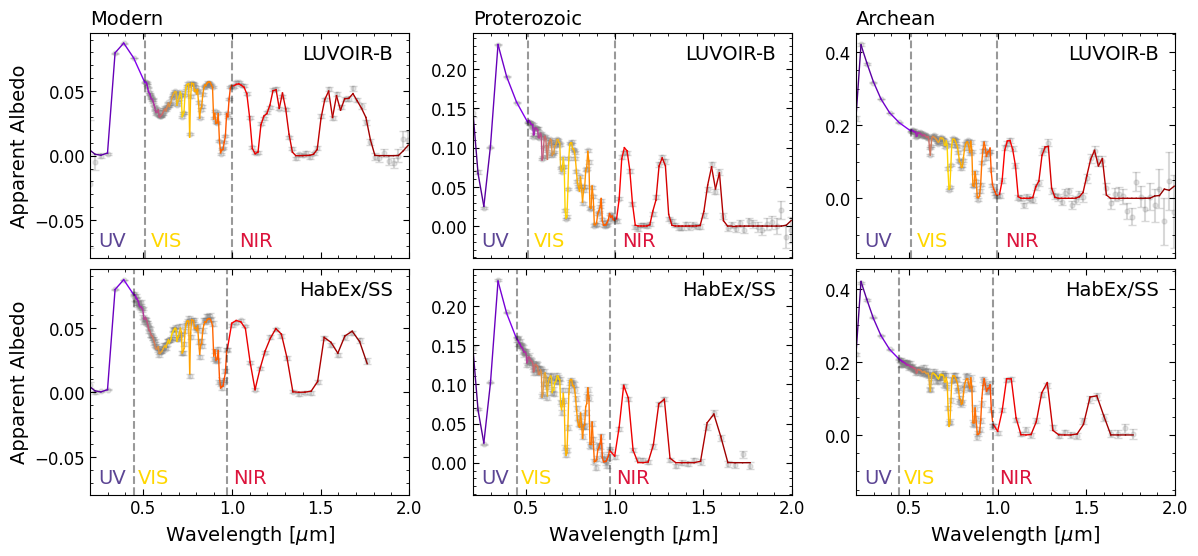

In [7]:
earth_types = ["modern", "proterozoic", "archean"]
sample_indices = {"modern": 50, "proterozoic": 52, "archean": 54}
random_seed = 42
output_path = "../images/sample_spectra.pdf"

rng = np.random.default_rng(random_seed)

earth_col = "Earth_type"

gradient_maps = {
    "B-UV": ["#4B0082", "#8B00FF"],
    "B-Vis": ["#9400D3", "#FFD700", "#FF4500"],
    "B-NIR": ["#FF0000", "#8B0000"],
    "SS-UV": ["#4B0082", "#8B00FF"],
    "SS-Vis": ["#9400D3", "#FFD700", "#FF4500"],
    "SS-NIR": ["#FF0000", "#8B0000"],
}

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 6), sharex=True, sharey="col")

for j, earth_type in enumerate(earth_types):
    sub = df[df[earth_col].str.lower() == earth_type].reset_index(drop=True)

    if sample_indices is not None and earth_type in sample_indices:
        idx = min(sample_indices[earth_type], len(sub) - 1)
    else:
        idx = rng.integers(0, len(sub))

    row = sub.iloc[idx]

    for row_i, instruments in enumerate(
        [["B-UV", "B-Vis", "B-NIR"], ["SS-UV", "SS-Vis", "SS-NIR"]]
    ):
        ax = axes[row_i, j]
        noisy_label_added = False

        for instrument in instruments:
            wl = np.asarray(WAVELENGTHS[instrument])
            albedo = np.asarray(row[f"ALBEDO_{instrument}"])
            noisy = np.asarray(row[f"NOISY_ALBEDO_{instrument}"])
            noise = np.asarray(row[f"NOISE_{instrument}"])

            n = min(len(wl), len(albedo), len(noisy), len(noise))
            wl, albedo, noisy, noise = wl[:n], albedo[:n], noisy[:n], noise[:n]

            lbl = "Noisy Data" if not noisy_label_added else "_nolegend_"
            noisy_label_added = True

            _, caps, bars = ax.errorbar(
                wl,
                noisy,
                yerr=noise,
                fmt=".",
                color="tab:gray",
                alpha=0.2,
                markersize=7,
                capsize=3,
                capthick=1,
                label=lbl,
                zorder=1,
            )
            [b.set_alpha(0.3) for b in bars]
            [c.set_alpha(0.3) for c in caps]

            cmap = mcolors.LinearSegmentedColormap.from_list(
                f"{instrument}_gradient", gradient_maps[instrument], N=max(n, 2)
            )
            for k in range(n - 1):
                ax.plot(
                    wl[k : k + 2],
                    albedo[k : k + 2],
                    color=cmap(k / max(n - 1, 1)),
                    lw=1,
                    zorder=2,
                )

        ax.set_xlim(0.2, 2.0)
        if row_i == 0:
            ax.axvline(WAVELENGTHS["B-UV"][-1], color="k", linestyle="--", alpha=0.4)
            ax.axvline(WAVELENGTHS["B-Vis"][-1], color="k", linestyle="--", alpha=0.4)
            ax.text(
                0.95, 0.95, "LUVOIR-B", transform=ax.transAxes, ha="right", va="top"
            )
            ax.set_title(earth_type.capitalize(), loc="left")
            ax.text(
                0.07, 0.05, "UV", color="#5C4594", transform=ax.transAxes, ha="center"
            )
            ax.text(
                0.24, 0.05, "VIS", color="#FFD700", transform=ax.transAxes, ha="center"
            )
            ax.text(
                0.52, 0.05, "NIR", color="#DC143C", transform=ax.transAxes, ha="center"
            )
            ax.set_xlabel("")
        else:
            ax.axvline(WAVELENGTHS["SS-UV"][-1], color="k", linestyle="--", alpha=0.4)
            ax.axvline(WAVELENGTHS["SS-Vis"][-1], color="k", linestyle="--", alpha=0.4)
            ax.text(
                0.95, 0.95, "HabEx/SS", transform=ax.transAxes, ha="right", va="top"
            )
            ax.text(
                0.07, 0.05, "UV", color="#5C4594", transform=ax.transAxes, ha="center"
            )
            ax.text(
                0.20, 0.05, "VIS", color="#FFD700", transform=ax.transAxes, ha="center"
            )
            ax.text(
                0.50, 0.05, "NIR", color="#DC143C", transform=ax.transAxes, ha="center"
            )
            ax.set_xlabel("Wavelength [$\\mu$m]")

        if j == 0:
            ax.set_ylabel("Apparent Albedo")
        else:
            ax.set_ylabel("")

plt.subplots_adjust(wspace=0.2, hspace=0.05)
# plt.savefig(output_path, bbox_inches="tight", dpi=300)
plt.show()

# Figure 2

In [8]:
def _kM_no_trailing_decimal(x, pos=None):
    x = float(x)
    if abs(x) < 1000:
        return f"{int(round(x))}"
    if abs(x) < 1_000_000:
        v = x / 1000.0
        s = f"{v:.1f}".rstrip("0").rstrip(".")
        return f"{s}k"
    v = x / 1_000_000.0
    s = f"{v:.1f}".rstrip("0").rstrip(".")
    return f"{s}M"

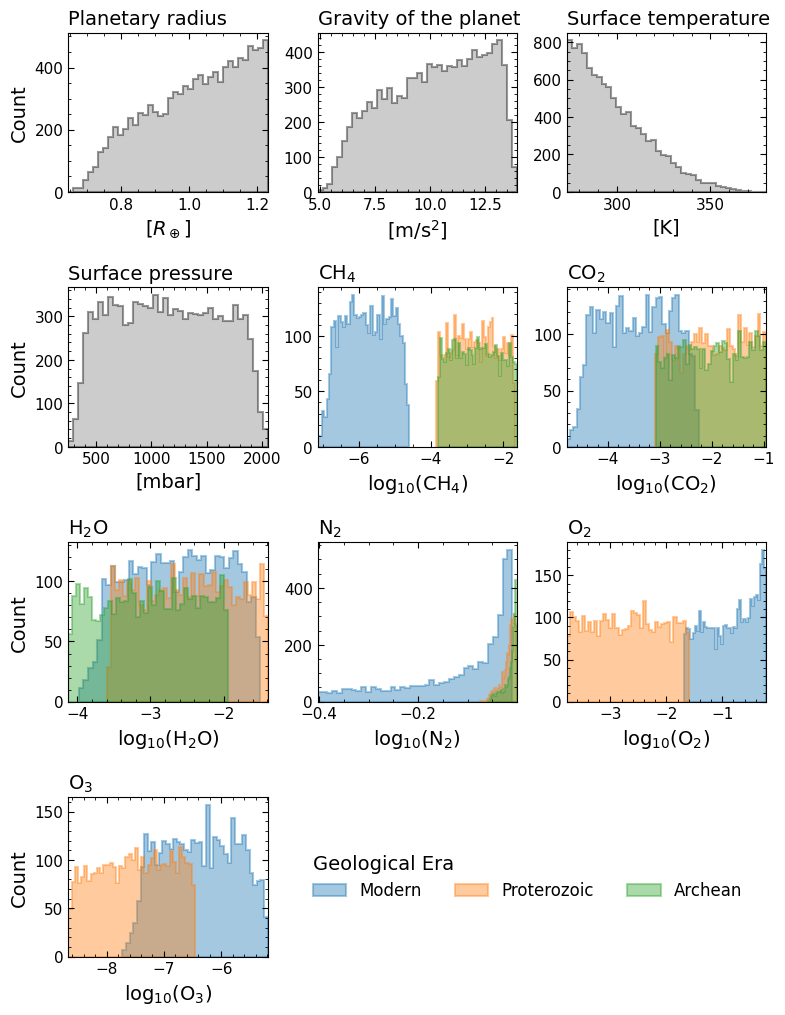

In [9]:
output_path = "../images/parameter_distributions.pdf"
bins = 40

PHYSICAL_PARAMS = [
    "OBJECT-RADIUS-REL-EARTH",
    "OBJECT-GRAVITY",
    "ATMOSPHERE-TEMPERATURE",
    "ATMOSPHERE-PRESSURE",
]
MOLECULES = ["CH4", "CO2", "H2O", "N2", "O2", "O3"]

ERA_COLORS = {
    "modern": "tab:blue",
    "proterozoic": "tab:orange",
    "archean": "tab:green",
}

param_labels = {
    "OBJECT-RADIUS-REL-EARTH": "Planetary radius",
    "OBJECT-GRAVITY": "Gravity of the planet",
    "ATMOSPHERE-TEMPERATURE": "Surface temperature",
    "ATMOSPHERE-PRESSURE": "Surface pressure",
}
param_units = {
    "OBJECT-RADIUS-REL-EARTH": "[$R_\\oplus$]",
    "OBJECT-GRAVITY": "[m/s$^2$]",
    "ATMOSPHERE-TEMPERATURE": "[K]",
    "ATMOSPHERE-PRESSURE": "[mbar]",
}
molecule_labels = {
    "CH4": "CH$_4$",
    "CO2": "CO$_2$",
    "H2O": "H$_2$O",
    "N2": "N$_2$",
    "O2": "O$_2$",
    "O3": "O$_3$",
}

fig, axes = plt.subplots(4, 3, figsize=(9, 12))
axes = axes.flatten()

for i, param in enumerate(PHYSICAL_PARAMS):
    ax = axes[i]
    all_values = pd.to_numeric(df[param], errors="coerce").dropna().to_numpy()

    ax.hist(
        all_values,
        bins=bins,
        alpha=0.4,
        color="gray",
        edgecolor="black",
        histtype="stepfilled",
        lw=1.5,
    )
    ax.set_xlabel(param_units[param])
    ax.set_ylabel("Count" if i % 3 == 0 else "")
    ax.set_title(param_labels[param], loc="left")
    ax.tick_params(axis="both", labelsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(_kM_no_trailing_decimal))
    if all_values.size > 0:
        ax.set_xlim(np.min(all_values), np.max(all_values))

for i, molecule in enumerate(MOLECULES):
    flat_idx = 4 + i
    ax = axes[flat_idx]
    all_log_values = []

    for era in ["modern", "proterozoic", "archean"]:
        vals = (
            pd.to_numeric(df.loc[df["Earth_type"] == era, molecule], errors="coerce")
            .dropna()
            .to_numpy()
        )
        vals = vals[vals > 0]

        if vals.size > 0:
            log_vals = np.log10(vals)
            all_log_values.extend(log_vals)
            ax.hist(
                log_vals,
                bins=bins,
                alpha=0.4,
                color=ERA_COLORS[era],
                edgecolor=ERA_COLORS[era],
                histtype="stepfilled",
                lw=1.5,
                label=era.capitalize(),
            )

    ax.set_xlabel(f"log$_{{10}}$({molecule_labels[molecule]})")
    ax.set_ylabel("Count" if flat_idx % 3 == 0 else "")
    ax.set_title(molecule_labels[molecule], loc="left")
    ax.tick_params(axis="both", labelsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(_kM_no_trailing_decimal))
    if len(all_log_values) > 0:
        ax.set_xlim(np.min(all_log_values), np.max(all_log_values))

axes[10].axis("off")
legend_elements = [
    Patch(
        facecolor=ERA_COLORS["modern"],
        alpha=0.4,
        edgecolor=ERA_COLORS["modern"],
        label="Modern",
        lw=1.5,
    ),
    Patch(
        facecolor=ERA_COLORS["proterozoic"],
        alpha=0.4,
        edgecolor=ERA_COLORS["proterozoic"],
        label="Proterozoic",
        lw=1.5,
    ),
    Patch(
        facecolor=ERA_COLORS["archean"],
        alpha=0.4,
        edgecolor=ERA_COLORS["archean"],
        label="Archean",
        lw=1.5,
    ),
]
leg = axes[10].legend(
    handles=legend_elements,
    loc="center left",
    bbox_to_anchor=(-0.1, 0.5),
    title="Geological Era",
    ncols=3,
)
leg.get_title().set_ha("left")
leg._legend_box.align = "left"

axes[11].axis("off")

plt.subplots_adjust(wspace=0.25, hspace=0.6)
# plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

# EDA

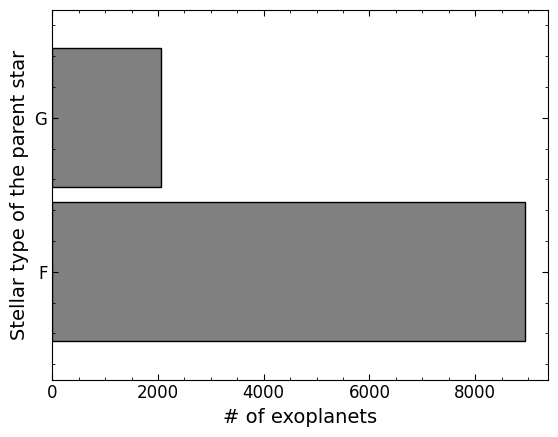

In [10]:
df["OBJECT-STAR-TYPE"].value_counts().plot(kind="barh", ec="k", width=0.9, color="gray")
plt.xticks(rotation=0)
plt.ylabel("Stellar type of the parent star"), plt.xlabel("# of exoplanets")
plt.show()

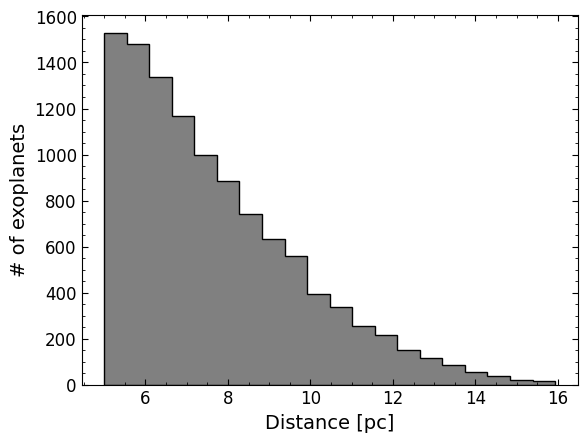

In [11]:
df["GEOMETRY-OBS-ALTITUDE"].hist(
    ec="k", bins=20, histtype="stepfilled", grid=False, color="gray"
)
plt.xlabel("Distance [pc]")
plt.ylabel("# of exoplanets")
plt.show()

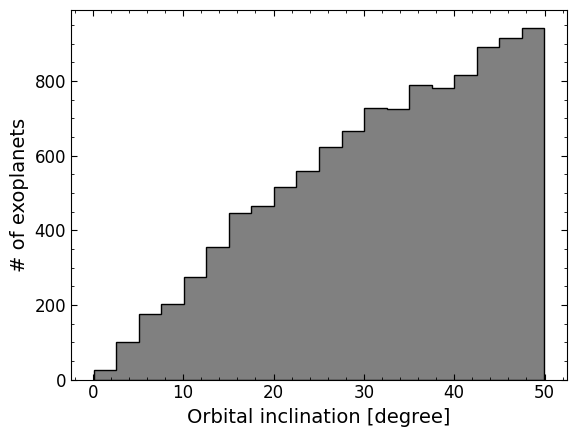

In [12]:
df["OBJECT-INCLINATION"].hist(
    ec="k", bins=20, histtype="stepfilled", grid=False, color="gray"
)
plt.xlabel("Orbital inclination [degree]")
plt.ylabel("# of exoplanets")
plt.show()

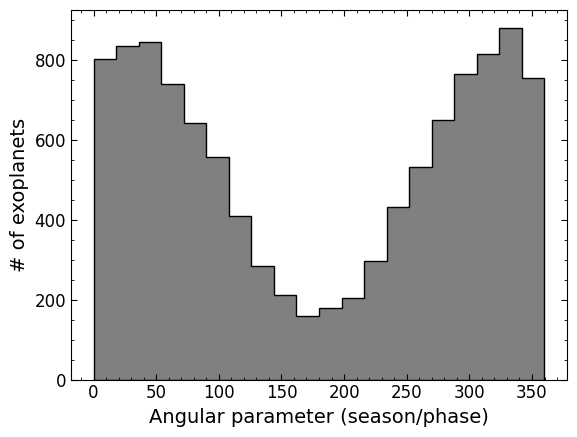

In [13]:
df["OBJECT-SEASON"].hist(
    ec="k", bins=20, histtype="stepfilled", grid=False, color="gray"
)
plt.xlabel("Angular parameter (season/phase)")
plt.ylabel("# of exoplanets")
plt.show()

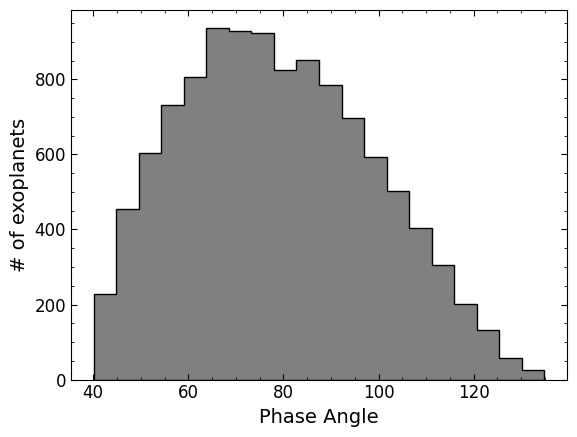

In [14]:
df["OBJECT-PHASE-ANGLE"].hist(
    ec="k", bins=20, histtype="stepfilled", grid=False, color="gray"
)
plt.xlabel("Phase Angle")
plt.ylabel("# of exoplanets")
plt.show()

# Analysis of noise influence

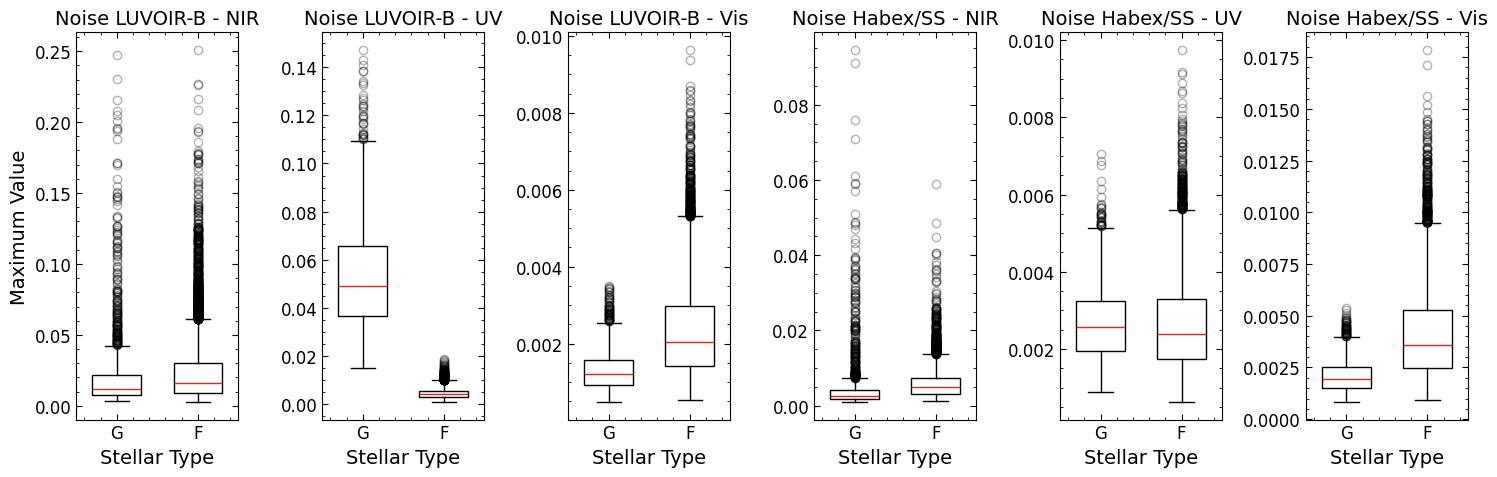

In [15]:
noise_columns = [col for col in df.columns if "NOISE_" in col]
data = df[noise_columns]

title_mapping = {"NOISE_": "Noise ", "B-": "LUVOIR-B - ", "SS-": "Habex/SS - "}

max_values_df = pd.DataFrame(
    {col: data[col].explode().groupby(level=0).max() for col in data.columns}
)

max_values_df["OBJECT-STAR-TYPE"] = df["OBJECT-STAR-TYPE"].values
stellar_types = max_values_df["OBJECT-STAR-TYPE"].unique()

plt.figure(figsize=(15, 5))
for i, col in enumerate(noise_columns):
    plt.subplot(1, len(noise_columns), i + 1)
    for j, stellar_type in enumerate(stellar_types):
        filtered_values = max_values_df[
            max_values_df["OBJECT-STAR-TYPE"] == stellar_type
        ][col]
        bp = plt.boxplot(
            filtered_values.dropna(),
            positions=[j],
            widths=0.6,
            patch_artist=True,
            boxprops=dict(facecolor="white", color="k", linewidth=1),
            medianprops=dict(color="tab:red", linewidth=1),
            whiskerprops=dict(color="k", linewidth=1),
            capprops=dict(color="k", linewidth=1),
            flierprops=dict(marker="o", color="tab:gray", alpha=0.3),
        )

    formatted_title = col
    for key, value in title_mapping.items():
        formatted_title = formatted_title.replace(key, value)
    plt.gcf().axes[i].set_title(formatted_title)

    plt.xticks(range(len(stellar_types)), stellar_types)
    plt.xlabel("Stellar Type")
    plt.ylabel("Maximum Value")

for i, ax in enumerate(plt.gcf().axes):
    if i > 0:
        ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [16]:
split_paths = {
    "train": os.path.join("../data/train.tfrecord"),
    "val": os.path.join("../data/val.tfrecord"),
    "test": os.path.join("../data/test.tfrecord"),
}

telescopes = ["B", "SS"]
bands = ["UV", "Vis", "NIR"]
bases = [f"{tel}-{band}" for tel in telescopes for band in bands]

feature_prefix = "SNR_FEATURE_PCTL_"


def collect_snr_from_tfrecord(tfrecord_path, bases):
    feature_description = {
        feature_prefix + base: tf.io.FixedLenFeature([], tf.float32) for base in bases
    }

    def _parse_fn(example_proto):
        return tf.io.parse_single_example(example_proto, feature_description)

    ds = tf.data.TFRecordDataset(tfrecord_path)
    ds = ds.map(_parse_fn).batch(4096)

    snr_dict = {base: [] for base in bases}

    for batch in ds:
        for base in bases:
            key = feature_prefix + base
            snr_dict[base].append(batch[key].numpy())

    for base in bases:
        if len(snr_dict[base]) > 0:
            snr_dict[base] = np.concatenate(snr_dict[base], axis=0)
        else:
            snr_dict[base] = np.array([])

    return snr_dict


snr_data = {}
for split, path in split_paths.items():
    snr_data[split] = collect_snr_from_tfrecord(path, bases)

for split in split_paths.keys():
    any_base = bases[0]
    print(split, snr_data[split][any_base].shape[0], "samples")

train 87954 samples
val 10993 samples
test 10998 samples


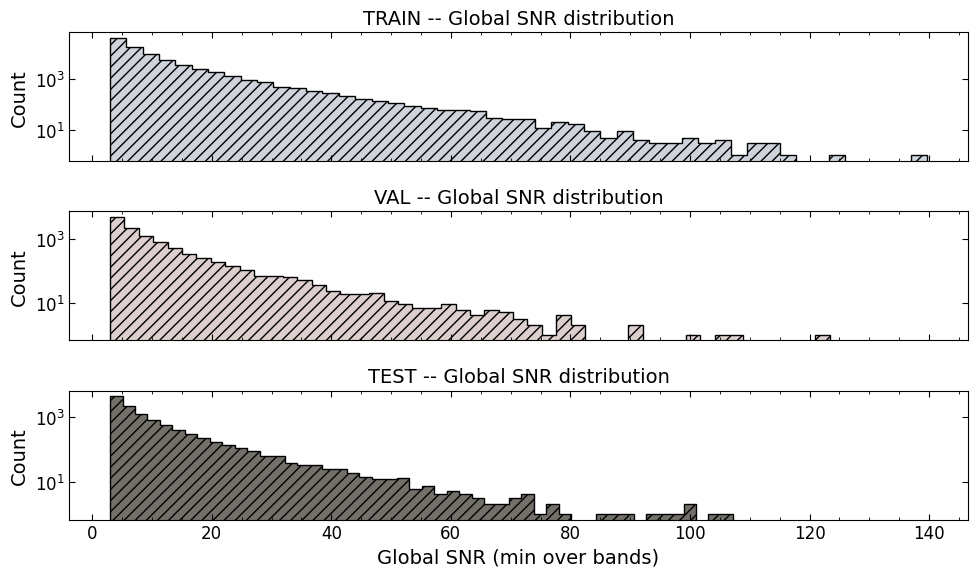

In [17]:
global_snr = {}

colors = {
    "train": "#ced3dc",
    "val": "#dccfce",
    "test": "#73706a",
}

for i, split in enumerate(["train", "val", "test"]):
    mat = np.stack([snr_data[split][base] for base in bases], axis=1)
    global_snr[split] = np.min(mat, axis=1)

fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

for ax, split in zip(axs, ["train", "val", "test"]):
    vals = global_snr[split]

    ax.hist(
        vals,
        bins=50,
        histtype="stepfilled",
        edgecolor="k",
        hatch="///",
        color=colors[split],
    )

    ax.set_yscale("log")
    ax.set_ylabel("Count")
    ax.set_title(f"{split.upper()} -- Global SNR distribution")

axs[-1].set_xlabel("Global SNR (min over bands)")

plt.tight_layout()
plt.show()

In [18]:
rows_global = []
for split in ["train", "val", "test"]:
    vals = global_snr[split]
    rows_global.append(
        {
            "Split": split,
            "Mean": np.mean(vals),
            "Median": np.median(vals),
            "Std": np.std(vals),
            "P5": np.percentile(vals, 5),
            "P50": np.percentile(vals, 50),
            "P95": np.percentile(vals, 95),
            "Min": np.min(vals),
            "Max": np.max(vals),
        }
    )

pd.DataFrame(rows_global).T

,0,1,2
Split,train,val,test
Mean,9.033384,8.997484,8.968853
Median,6.057475,6.053118,6.051074
Std,8.543666,8.564178,8.430973
P5,3.18482,3.184233,3.200174
P50,6.057475,6.053118,6.051074
P95,25.016962,24.788925,24.578249
Min,3.000116,3.000133,3.000111
Max,139.64357,123.366112,107.259819


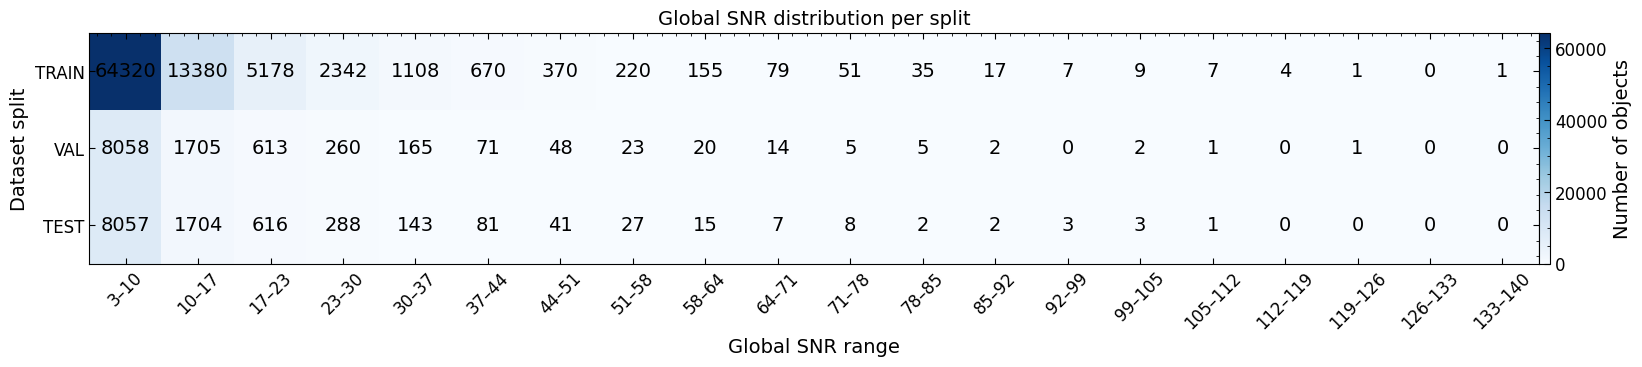

In [19]:
all_vals = np.concatenate([global_snr["train"], global_snr["val"], global_snr["test"]])

vmin, vmax = all_vals.min(), all_vals.max()
n_bins = 20
bins = np.linspace(vmin, vmax, n_bins + 1)

splits = ["train", "val", "test"]
heat = []

for split in splits:
    counts, _ = np.histogram(global_snr[split], bins=bins)
    heat.append(counts)

heat = np.array(heat)

xticks = [f"{bins[i]:.0f}–{bins[i+1]:.0f}" for i in range(len(bins) - 1)]
yticks = [s.upper() for s in splits]

fig, ax = plt.subplots(figsize=(22, 3))

im = ax.imshow(heat, cmap="Blues", aspect="auto")

ax.tick_params(which="minor", bottom=False, left=False)

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(
            j,
            i,
            f"{heat[i, j]:d}",
            ha="center",
            va="center",
            color="black",
        )

ax.set_xticks(np.arange(heat.shape[1]))
ax.set_yticks(np.arange(heat.shape[0]))
ax.set_xticklabels(xticks, rotation=45, ha="center")
ax.set_yticklabels(yticks)

ax.set_xlabel("Global SNR range")
ax.set_ylabel("Dataset split")
ax.set_title("Global SNR distribution per split")

cbar = fig.colorbar(im, ax=ax, pad=0)
cbar.set_label("Number of objects")
plt.show()

# Data distribution (paper tables)

In [20]:
features = [
    "OBJECT-RADIUS-REL-EARTH",
    "OBJECT-GRAVITY",
    "ATMOSPHERE-TEMPERATURE",
    "ATMOSPHERE-PRESSURE",
    "CH4",
    "CO2",
    "H2O",
    "N2",
    "O2",
    "O3",
]


def to_sci_notation(x):
    if pd.isna(x):
        return "NaN"
    if x <= 0:
        return "0"
    return np.format_float_scientific(x, precision=10, unique=True)


data = []
for et in ["modern", "proterozoic", "archean"]:
    sub = df[df["Earth_type"] == et]

    for feature in features:
        vals = pd.to_numeric(sub[feature], errors="coerce").dropna().to_numpy()
        if vals.size == 0:
            min_val, max_val = np.nan, np.nan
        else:
            min_val, max_val = np.min(vals), np.max(vals)

        data.append(
            {
                "Earth Type": et,
                "Feature": feature,
                "Min": to_sci_notation(min_val),
                "Max": to_sci_notation(max_val),
            }
        )

df_stats = pd.DataFrame(data)

for et in df_stats["Earth Type"].unique():
    print(f">> {et.upper()}")
    display(df_stats[df_stats["Earth Type"] == et].iloc[:, 1:])

>> MODERN


,Feature,Min,Max
0,OBJECT-RADIUS-REL-EARTH,6.6259694099e-01,1.2299981117e+00
1,OBJECT-GRAVITY,5.1428351402e+00,1.3934196472e+01
2,ATMOSPHERE-TEMPERATURE,2.7315515137e+02,3.7960659790e+02
3,ATMOSPHERE-PRESSURE,2.7913330078e+02,2.0491337891e+03
4,CH4,7.2799217321e-08,2.525963464e-05
5,CO2,1.6059049813e-05,5.5455192924e-03
6,H2O,1.0473027214e-04,3.1928651035e-02
7,N2,3.9496162534e-01,9.7761583328e-01
8,O2,2.1032221615e-02,6.0487055779e-01
9,O3,1.8836466609e-08,6.4487453528e-06


>> PROTEROZOIC


,Feature,Min,Max
10,OBJECT-RADIUS-REL-EARTH,6.4652830362e-01,1.2299993038e+00
11,OBJECT-GRAVITY,4.8727617264e+00,1.3921819687e+01
12,ATMOSPHERE-TEMPERATURE,2.7317227173e+02,3.747598877e+02
13,ATMOSPHERE-PRESSURE,2.5058598328e+02,2.0454952393e+03
14,CH4,1.364088821e-04,2.1289596334e-02
15,CO2,8.1263156608e-04,1.0971185565e-01
16,H2O,2.5578512577e-04,4.0272768587e-02
17,N2,8.4148341417e-01,9.9827063084e-01
18,O2,1.6448523093e-04,2.5151066482e-02
19,O3,2.1615971235e-09,3.4780330793e-07


>> ARCHEAN


,Feature,Min,Max
20,OBJECT-RADIUS-REL-EARTH,6.6614961624e-01,1.2298705578e+00
21,OBJECT-GRAVITY,5.1591377258e+00,1.3895880699e+01
22,ATMOSPHERE-TEMPERATURE,2.7315301514e+02,3.7457446289e+02
23,ATMOSPHERE-PRESSURE,2.8090579224e+02,2.0378800049e+03
24,CH4,1.5566784714e-04,2.3399380967e-02
25,CO2,8.2622893387e-04,1.0968620330e-01
26,H2O,7.5253206887e-05,1.1598128825e-02
27,N2,8.7477731705e-01,9.9863129854e-01
28,O2,0,0
29,O3,0,0


# How many planets can retain atmospheres?

In [23]:
n = 100_000
spt = ["F", "G", "K"]

mainseq = {
    "F": {
        "teff": np.array(
            [5990, 6050, 6180, 6280, 6350, 6550, 6670, 6750, 6820, 7020, 7220]
        ),
        "radius": np.array(
            [
                1.142,
                1.167,
                1.221,
                1.324,
                1.359,
                1.473,
                1.533,
                1.578,
                1.622,
                1.679,
                1.728,
            ],
            dtype=float,
        ),
    },
    "G": {
        "teff": np.array(
            [5380, 5480, 5550, 5600, 5660, 5680, 5720, 5770, 5860, 5930], dtype=float
        ),
        "radius": np.array(
            [0.853, 0.914, 0.927, 0.949, 0.977, 0.991, 1.002, 1.012, 1.060, 1.100],
            dtype=float,
        ),
    },
    "K": {
        "teff": np.array(
            [3930, 3990, 4100, 4300, 4440, 4600, 4830, 5100, 5170, 5270], dtype=float
        ),
        "radius": np.array(
            [0.608, 0.615, 0.630, 0.669, 0.701, 0.713, 0.755, 0.783, 0.797, 0.813],
            dtype=float,
        ),
    },
}


def sample_star():
    stellar_class = np.random.choice(spt)
    sequence = mainseq[stellar_class]

    stellar_temperature = np.random.uniform(
        sequence["teff"][0], min(sequence["teff"][-1], 7200.0)
    )

    # Logarithmic interpolation of radius as a function of Teff
    stellar_radius = np.exp(
        np.interp(stellar_temperature, sequence["teff"], np.log(sequence["radius"]))
    )

    stellar_luminosity = (
        4.0
        * np.pi
        * (stellar_radius * R_sun.value) ** 2
        * sigma_sb.value
        * stellar_temperature**4
    )
    stellar_luminosity_solar = stellar_luminosity / L_sun.value

    return stellar_class, stellar_temperature, stellar_radius, stellar_luminosity_solar


def calculate_habitable_zone(stellar_temperature, stellar_luminosity_solar):
    temperature_offset = stellar_temperature - 5780.0

    # Recent Venus: inner boundary
    recent_venus_flux = (
        1.776
        + 2.136e-4 * temperature_offset
        + 2.533e-8 * temperature_offset**2
        - 1.332e-11 * temperature_offset**3
        - 3.097e-15 * temperature_offset**4
    )

    # Early Mars: outer boundary
    early_mars_flux = (
        0.32
        + 5.547e-5 * temperature_offset
        + 1.526e-9 * temperature_offset**2
        - 2.874e-12 * temperature_offset**3
        - 5.011e-16 * temperature_offset**4
    )

    inner_distance = np.sqrt(stellar_luminosity_solar / recent_venus_flux)
    outer_distance = np.sqrt(stellar_luminosity_solar / early_mars_flux)

    return inner_distance, outer_distance


def calculate_boiling_point(pressure_mbar):
    reference_pressure_mbar = 1013.25
    reference_temperature_k = 373.15
    latent_heat_j_mol = 40.65e3

    return 1.0 / (
        1.0 / reference_temperature_k
        - (R.value / latent_heat_j_mol)
        * np.log(pressure_mbar / reference_pressure_mbar)
    )


def test_planet():
    stellar_class, stellar_temperature, stellar_radius, stellar_luminosity_solar = (
        sample_star()
    )

    # Optimistic habitable-zone limits
    inner_distance, outer_distance = calculate_habitable_zone(
        stellar_temperature, stellar_luminosity_solar
    )

    semi_major_axis = np.random.uniform(inner_distance, outer_distance)

    # Planet radius and mass
    planet_radius = np.random.uniform(0.3, 1.23)

    mass_radius_exponent = 0.279 + np.random.uniform(-0.009, 0.009)

    planet_mass = planet_radius ** (1.0 / mass_radius_exponent)

    planet_radius_m = planet_radius * R_earth.value

    gravity = G.value * (planet_mass * M_earth.value) / planet_radius_m**2

    escape_velocity = np.sqrt(2.0 * gravity * planet_radius_m)

    # Insolation in Earth units
    real_insolation = stellar_luminosity_solar / semi_major_axis**2

    # Cosmic shoreline
    cosmic_shoreline = 5.0e-16 * escape_velocity**4

    if real_insolation >= cosmic_shoreline:
        return "Cannot retain atmosphere"

    # Surface pressure
    pressure_exponent = 3.168 + np.random.uniform(-0.232, 0.232)

    pressure_mbar = 1013.25 * planet_radius**pressure_exponent

    # Independent shortwave albedo and atmospheric IR emissivity
    shortwave_albedo = np.random.uniform(0.06, 0.96)

    atmospheric_ir_emissivity = np.random.uniform(0.0, 1.0)

    equilibrium_temperature = (
        (1.0 - shortwave_albedo) * real_insolation * 1361.0 / (4.0 * sigma_sb.value)
    ) ** 0.25

    surface_temperature = (
        equilibrium_temperature * (2.0 / (2.0 - atmospheric_ir_emissivity)) ** 0.25
    )

    # Pure-water triple-point pressure
    if pressure_mbar * 100.0 <= 611.657:
        return "Pressure below water triple point"

    boiling_temperature = calculate_boiling_point(pressure_mbar)

    if surface_temperature < 273.15:
        return "Surface below freezing point"

    if surface_temperature > boiling_temperature:
        return "Surface above boiling point"

    return "Liquid-water criterion satisfied"


def run_simulations(n=n):

    outcomes = {
        "Cannot retain atmosphere": 0,
        "Pressure below water triple point": 0,
        "Surface below freezing point": 0,
        "Surface above boiling point": 0,
        "Liquid-water criterion satisfied": 0,
    }

    for _ in range(n):
        result = test_planet()
        outcomes[result] += 1

    return outcomes


results = run_simulations()

without_atmosphere = results["Cannot retain atmosphere"]
with_atmosphere = n - without_atmosphere

print("ATMOSPHERIC RETENTION")
print(
    f"Planets retaining atmosphere: {with_atmosphere:,} ({100 * with_atmosphere / n:.2f}%)"
)
print(
    f"Planets not retaining atmosphere: {without_atmosphere:,} ({100 * without_atmosphere / n:.2f}%)"
)

print("\nCOMPLETE CLASSIFICATION")

for outcome, count in results.items():
    percentage = 100.0 * count / n

    print(f"{outcome}: {count:,} ({percentage:.2f}%)")

ATMOSPHERIC RETENTION
Planets retaining atmosphere: 65,281 (65.28%)
Planets not retaining atmosphere: 34,719 (34.72%)

COMPLETE CLASSIFICATION
Cannot retain atmosphere: 34,719 (34.72%)
Pressure below water triple point: 0 (0.00%)
Surface below freezing point: 57,112 (57.11%)
Surface above boiling point: 12 (0.01%)
Liquid-water criterion satisfied: 8,157 (8.16%)
